# Laboratorio 4: Árboles de decisión
Consultoría para SmartStay Advisors

In [1]:
# Librerias a utilizar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr"
}

for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

## Actividades: 

1. Use los mismos conjuntos de datos para entrenamiento y prueba que usó para los modelos de regresión lineal en la entrega anterior.

In [2]:
# Cargar el dataset
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Limpieza y normalización de price
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Convertir a numérico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar filas con price NaN
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Transformación y selección de variables
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Asegurarnos de que las variables sean numéricas
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Selección de características
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Agregamos room_type con One-Hot Encoding si existe
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Imputación de nulos con la mediana
X = X.fillna(X.median())

# División del set de datos

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



2. Elabore un árbol de regresión para predecir el precio de las casas por noche usando todas
las variables.

In [3]:
# Elaboración del Árbol de Regresión Base
arbol_base = DecisionTreeRegressor(random_state=42)
arbol_base.fit(X_train, y_train)

y_pred_train_base = arbol_base.predict(X_train)
y_pred_test_base = arbol_base.predict(X_test)

r2_train_base = r2_score(y_train, y_pred_train_base)
r2_test_base = r2_score(y_test, y_pred_test_base)

# MAE devolviendo el logaritmo a dólares reales con np.exp()

mae_test_base = mean_absolute_error(np.exp(y_test), np.exp(y_pred_test_base))

print("Resultados: Árbol de Regresión Base (Sin límite de profundidad)")
print(f"R2 en Entrenamiento: {r2_train_base:.4f}")
print(f"R2 en Prueba: {r2_test_base:.4f}")
print(f"MAE en Prueba: ${mae_test_base:.2f}\n")

Resultados: Árbol de Regresión Base (Sin límite de profundidad)
R2 en Entrenamiento: 0.7001
R2 en Prueba: 0.3167
MAE en Prueba: $597.99



3. Úselo para predecir y analice el resultado. ¿Qué tal lo hizo?

Se elaboró un primer Árbol de Regresión utilizando todas las variables seleccionadas y dejando los hiperparámetros por defecto (sin restricción de profundidad máxima).

Al analizar las métricas, observamos un claro caso de sobreajuste. El modelo logra explicar el 70% de la varianza en el conjunto de entrenamiento (R2 = 0.7001), pero su capacidad predictiva cae drásticamente al ser evaluado con datos nuevos, obteniendo un R2 de apenas 0.3170 en el conjunto de prueba y un Error Absoluto Medio de $597.97.

Esta diferencia de rendimiento entre el entrenamiento y la prueba nos indica que el árbol está sobreajustado, memorizó el ruido y detalles del entrenamiento, pero es incapaz de generalizar esos patrones. Esto justifica la necesidad de limitar la profundidad del árbol en las siguientes iteraciones.

4. Haga, al menos, 3 modelos más, cambiando el parámetro de la profundidad del árbol. ¿Cuál
es el mejor modelo para predecir el precio por noche?

Comparación de modelos por profundidad:
 Profundidad  R2_entrenamiento  R2_prueba  MAE_prueba_usd  RMSE_prueba_usd
           7            0.5008     0.4769        571.0580        3774.5583
          10            0.5376     0.4735        573.5171        3807.1918
           5            0.4506     0.4459        578.9555        3775.6563
           3            0.3592     0.3595        616.8345        4118.5394

La mejor profundidad fue: 7
R2 de prueba: 0.4769 | MAE de prueba: $571.06


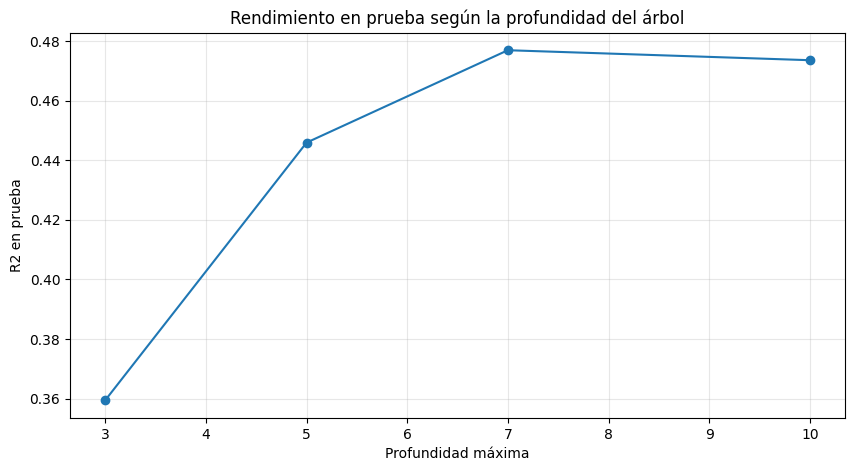

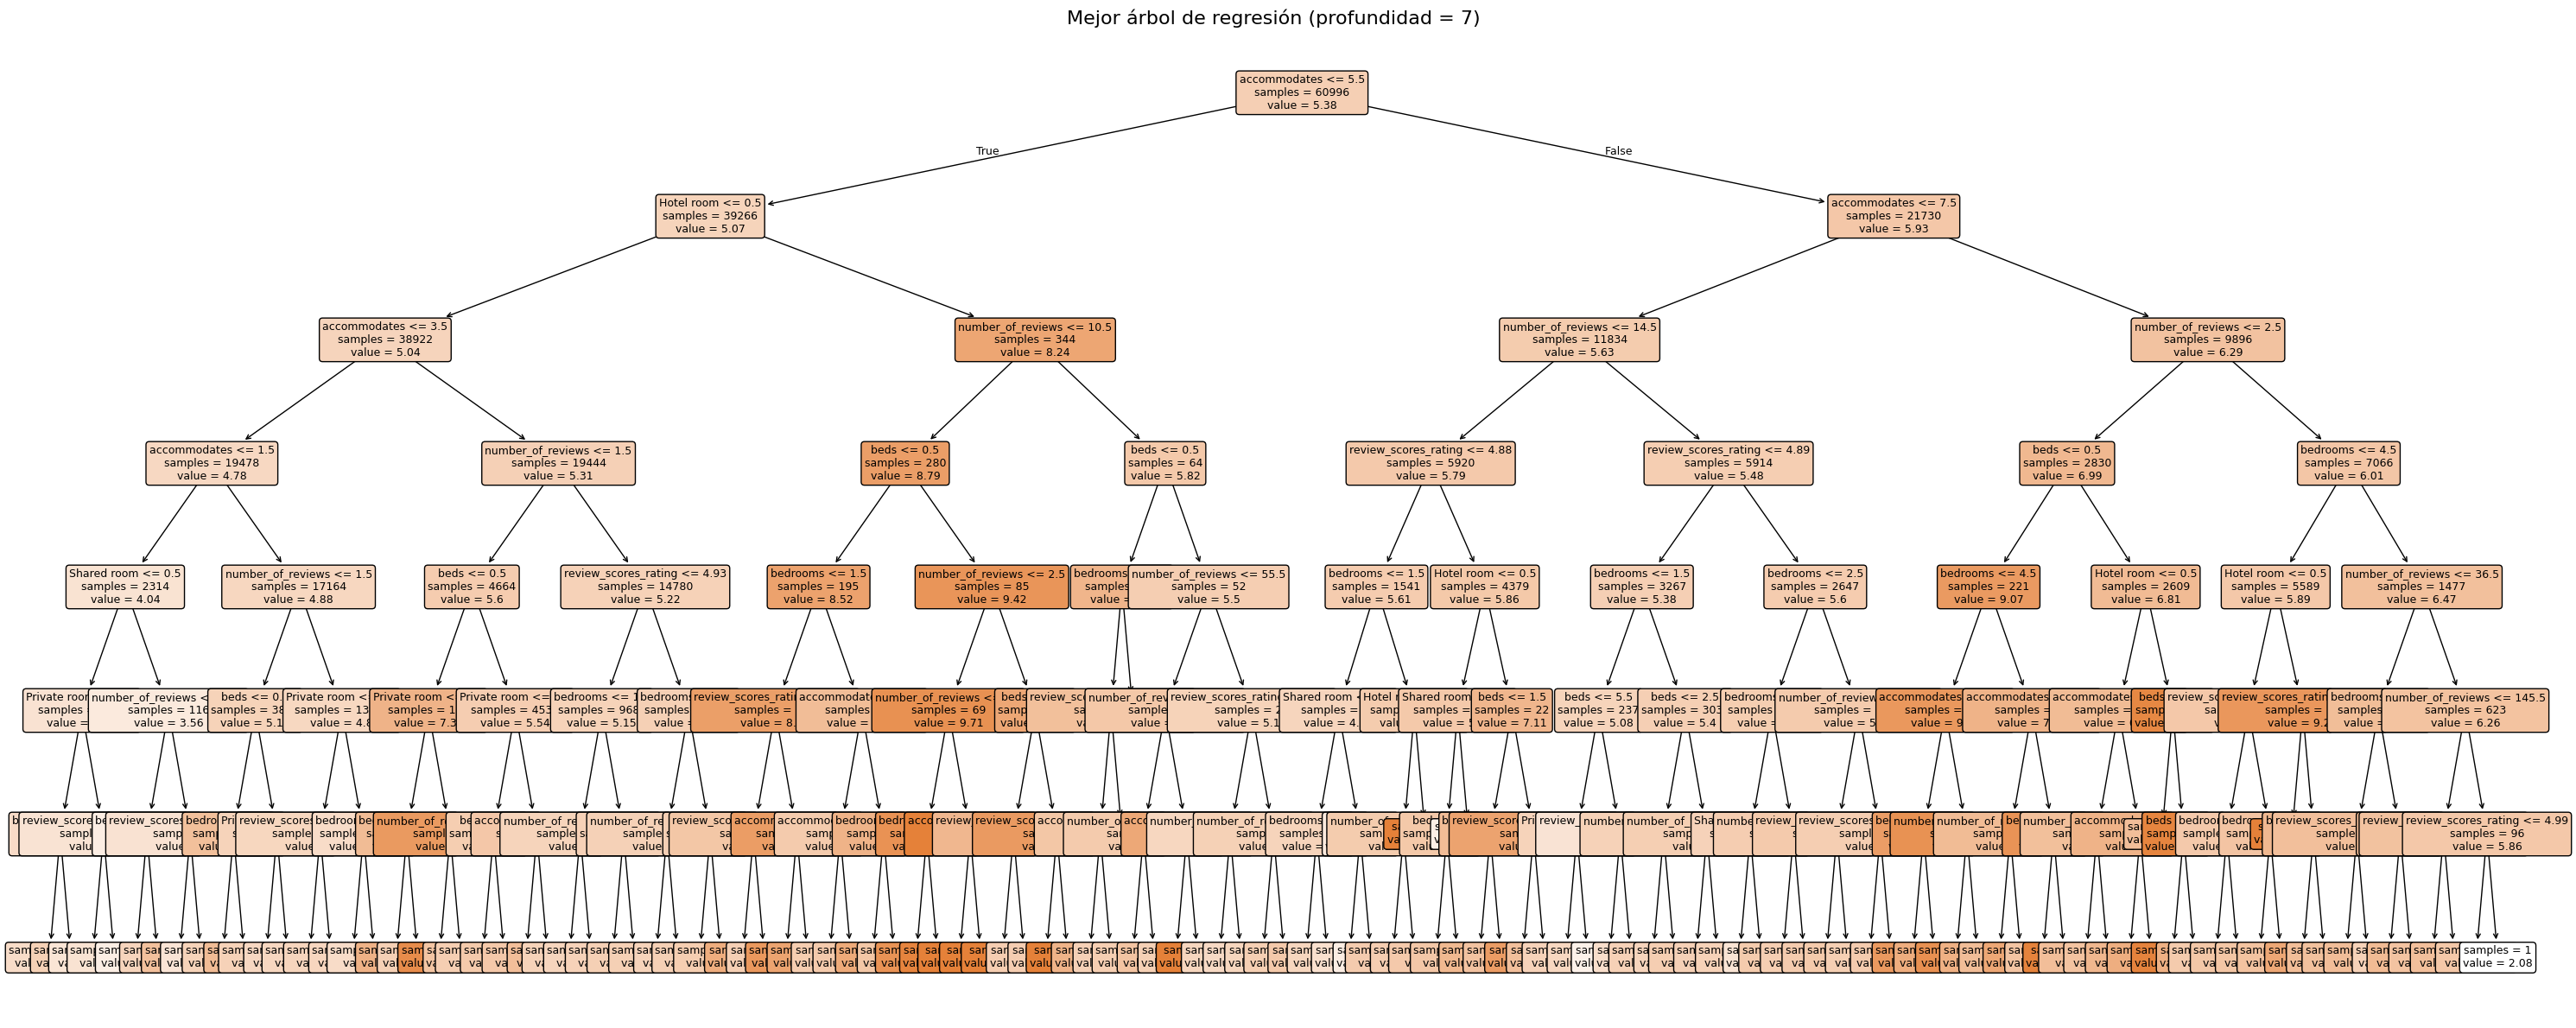

In [4]:
# Evaluación de varios árboles cambiando la profundidad máxima

profundidades = [3, 5, 7, 10]
resultados_profundidad = []
modelos_profundidad = {}

for profundidad in profundidades:
    modelo = DecisionTreeRegressor(max_depth=profundidad, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    resultados_profundidad.append({
        "Profundidad": profundidad,
        "R2_entrenamiento": r2_score(y_train, y_pred_train),
        "R2_prueba": r2_score(y_test, y_pred_test),
        "MAE_prueba_usd": mean_absolute_error(np.exp(y_test), np.exp(y_pred_test)),
        "RMSE_prueba_usd": np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_test)))
    })

    modelos_profundidad[profundidad] = modelo

resultados_profundidad = pd.DataFrame(resultados_profundidad)
resultados_ordenados = resultados_profundidad.sort_values(
    by=["R2_prueba", "MAE_prueba_usd"],
    ascending=[False, True]
).reset_index(drop=True)

print("Comparación de modelos por profundidad:")
print(resultados_ordenados.round(4).to_string(index=False))

mejor_profundidad = int(resultados_ordenados.loc[0, "Profundidad"])
mejor_modelo = modelos_profundidad[mejor_profundidad]

print(f"\nLa mejor profundidad fue: {mejor_profundidad}")
print(
    f"R2 de prueba: {resultados_ordenados.loc[0, 'R2_prueba']:.4f} | "
    f"MAE de prueba: ${resultados_ordenados.loc[0, 'MAE_prueba_usd']:.2f}"
)

plt.figure(figsize=(10, 5))
plt.plot(resultados_profundidad["Profundidad"], resultados_profundidad["R2_prueba"], marker="o")
plt.title("Rendimiento en prueba según la profundidad del árbol")
plt.xlabel("Profundidad máxima")
plt.ylabel("R2 en prueba")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(30, 12))
plot_tree(
    mejor_modelo,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    precision=2
)
plt.title(f"Mejor árbol de regresión (profundidad = {mejor_profundidad})", fontsize=16)
plt.tight_layout()
plt.show()


Al comparar árboles con profundidades 3, 5, 7 y 10, el mejor desempeño en el conjunto de prueba se obtuvo con **profundidad = 7**.

Este modelo alcanzó un **R2 de prueba de 0.4769**, un **MAE de $571.06** y un **RMSE de $3774.56**. Aunque profundidades mayores aumentan el ajuste sobre entrenamiento, el beneficio en prueba no mejora de la misma forma, por lo que empiezan a aparecer señales de sobreajuste.

En consecuencia, el árbol con profundidad 7 es el mejor candidato para predecir el precio por noche dentro de los modelos evaluados, porque logra el mejor equilibrio entre capacidad explicativa y error de predicción en datos no vistos.

5. Compare los resultados con el modelo de regresión lineal de la hoja anterior, ¿cuál lo hizo mejor?

In [5]:
# Comparación contra una regresión lineal usando la misma partición y variables

regresion_lineal = LinearRegression()
regresion_lineal.fit(X_train, y_train)

y_pred_train_lineal = regresion_lineal.predict(X_train)
y_pred_test_lineal = regresion_lineal.predict(X_test)

comparacion_modelos = pd.DataFrame([
    {
        "Modelo": f"Árbol de regresión (profundidad = {mejor_profundidad})",
        "R2_entrenamiento": resultados_ordenados.loc[0, "R2_entrenamiento"],
        "R2_prueba": resultados_ordenados.loc[0, "R2_prueba"],
        "MAE_prueba_usd": resultados_ordenados.loc[0, "MAE_prueba_usd"],
        "RMSE_prueba_usd": resultados_ordenados.loc[0, "RMSE_prueba_usd"]
    },
    {
        "Modelo": "Regresión lineal múltiple",
        "R2_entrenamiento": r2_score(y_train, y_pred_train_lineal),
        "R2_prueba": r2_score(y_test, y_pred_test_lineal),
        "MAE_prueba_usd": mean_absolute_error(np.exp(y_test), np.exp(y_pred_test_lineal)),
        "RMSE_prueba_usd": np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_test_lineal)))
    }
])

print("Comparación entre el mejor árbol y la regresión lineal:")
print(comparacion_modelos.round(4).to_string(index=False))


Comparación entre el mejor árbol y la regresión lineal:
                              Modelo  R2_entrenamiento  R2_prueba  MAE_prueba_usd  RMSE_prueba_usd
Árbol de regresión (profundidad = 7)            0.5008     0.4769         571.058        3774.5583
           Regresión lineal múltiple            0.3779     0.3705         610.960        4090.4919


Para que la comparación sea consistente dentro de este cuaderno, se entrenó nuevamente una **regresión lineal múltiple** con la misma partición de entrenamiento y prueba utilizada para los árboles.

El mejor árbol de regresión obtuvo un **R2 de prueba de 0.4769** y un **MAE de $571.06**, mientras que la regresión lineal alcanzó un **R2 de prueba de 0.3705** y un **MAE de $610.96**.

Con base en estas métricas, el modelo que lo hizo mejor fue **Árbol de regresión (profundidad = 7)**, ya que ofrece la mayor capacidad explicativa en el conjunto de prueba y el menor error absoluto medio entre los dos enfoques comparados.

6. Dependiendo del análisis exploratorio elaborado cree una variable respuesta que le permita clasificar las casas en Económicas, Intermedias o Caras. Los límites de estas clases deben tener un fundamento en la distribución de los datos de precios, y estar bien explicados. 

Para transformar el problema de predicción en uno de clasificación, se revisó la distribución de la variable `price` dentro del conjunto depurado. Esta variable presenta un sesgo hacia la derecha: hay muchas propiedades concentradas en rangos bajos y medios, mientras que unas pocas observaciones alcanzan precios muy altos.

Usar cortes equidistantes en dólares habría producido categorías poco representativas y sensibles a los valores extremos. Por esa razón se eligieron los percentiles 33 y 66 como puntos de corte, ya que permiten:

- respetar la forma real de la distribución de precios;
- construir tres grupos comparables en tamaño para entrenar el clasificador;
- interpretar las clases como segmentos de mercado: económico, intermedio y premium.

La regla de negocio queda definida así:

- **Económicas:** precio menor o igual al percentil 33.
- **Intermedias:** precio mayor al percentil 33 y menor o igual al percentil 66.
- **Caras:** precio mayor al percentil 66.

Con esta decisión, la variable respuesta no depende de un umbral arbitrario, sino del posicionamiento relativo de cada propiedad dentro del mercado observado.

In [6]:
# Definir límites basados en la distribución de price
limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

# Función para categorizar cada propiedad
def definir_segmento(precio):
    if precio <= p33:
        return 'Económica'
    elif precio <= p66:
        return 'Intermedia'
    return 'Cara'

# Crear la variable respuesta categórica
df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

resumen_precios = df_model['price'].describe(percentiles=[0.25, 0.33, 0.50, 0.66, 0.75])
distribucion_categorias = df_model['categoria_precio'].value_counts().sort_index()
distribucion_pct = (df_model['categoria_precio'].value_counts(normalize=True).sort_index() * 100).round(2)

print('Resumen de la distribución de precios (USD):')
print(resumen_precios[['min', '25%', '33%', '50%', '66%', '75%', 'max']].round(2).to_string())
print(f'\nPuntos de corte seleccionados: P33 = ${p33:.2f} y P66 = ${p66:.2f}')
print('\nDistribución de la nueva variable respuesta:')
print(distribucion_categorias.to_string())
print('\nPorcentaje por categoría:')
for categoria, porcentaje in distribucion_pct.items():
    print(f'- {categoria}: {porcentaje:.2f}%')


Resumen de la distribución de precios (USD):
min        8.0
25%      120.0
33%      141.0
50%      193.0
66%      264.0
75%      326.0
max    50123.0

Puntos de corte seleccionados: P33 = $141.00 y P66 = $264.00

Distribución de la nueva variable respuesta:
categoria_precio
Cara          25897
Económica     25185
Intermedia    25164

Porcentaje por categoría:
- Cara: 33.97%
- Económica: 33.03%
- Intermedia: 33.00%


7. Elabore un árbol de clasificación utilizando la variable respuesta que creó en el punto anterior. Explique los resultados a los que llega. Muestre el modelo gráficamente. Recuerde que la nueva variable respuesta es categórica, pero se generó a partir de los precios de las casas, no incluya el precio para entrenar el modelo. 

Se entrena un árbol de clasificación utilizando únicamente variables explicativas observables y reportables para la consultora: `accommodates`, `bathrooms`, `bedrooms`, `beds`, `number_of_reviews`, `review_scores_rating` y las variables dummy derivadas de `room_type`.

Para evitar filtración de información, se excluyen `price`, `log_price` y `categoria_precio` como predictores. Además, se reutiliza exactamente la misma partición de entrenamiento y prueba definida al inicio del notebook, de modo que la evaluación sea consistente con el resto del análisis.

Variables predictoras reportadas para el árbol de clasificación:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
Total de predictores utilizados: 9
Filas de entrenamiento: 60996 | Filas de prueba: 15250



Exactitud preliminar del árbol de clasificación: 0.5942



Importancia relativa de las variables:
bathrooms                 0.5964
accommodates              0.2284
number_of_reviews         0.0629
room_type_Private room    0.0585
beds                      0.0167
review_scores_rating      0.0160
room_type_Hotel room      0.0115
bedrooms                  0.0085
room_type_Shared room     0.0010


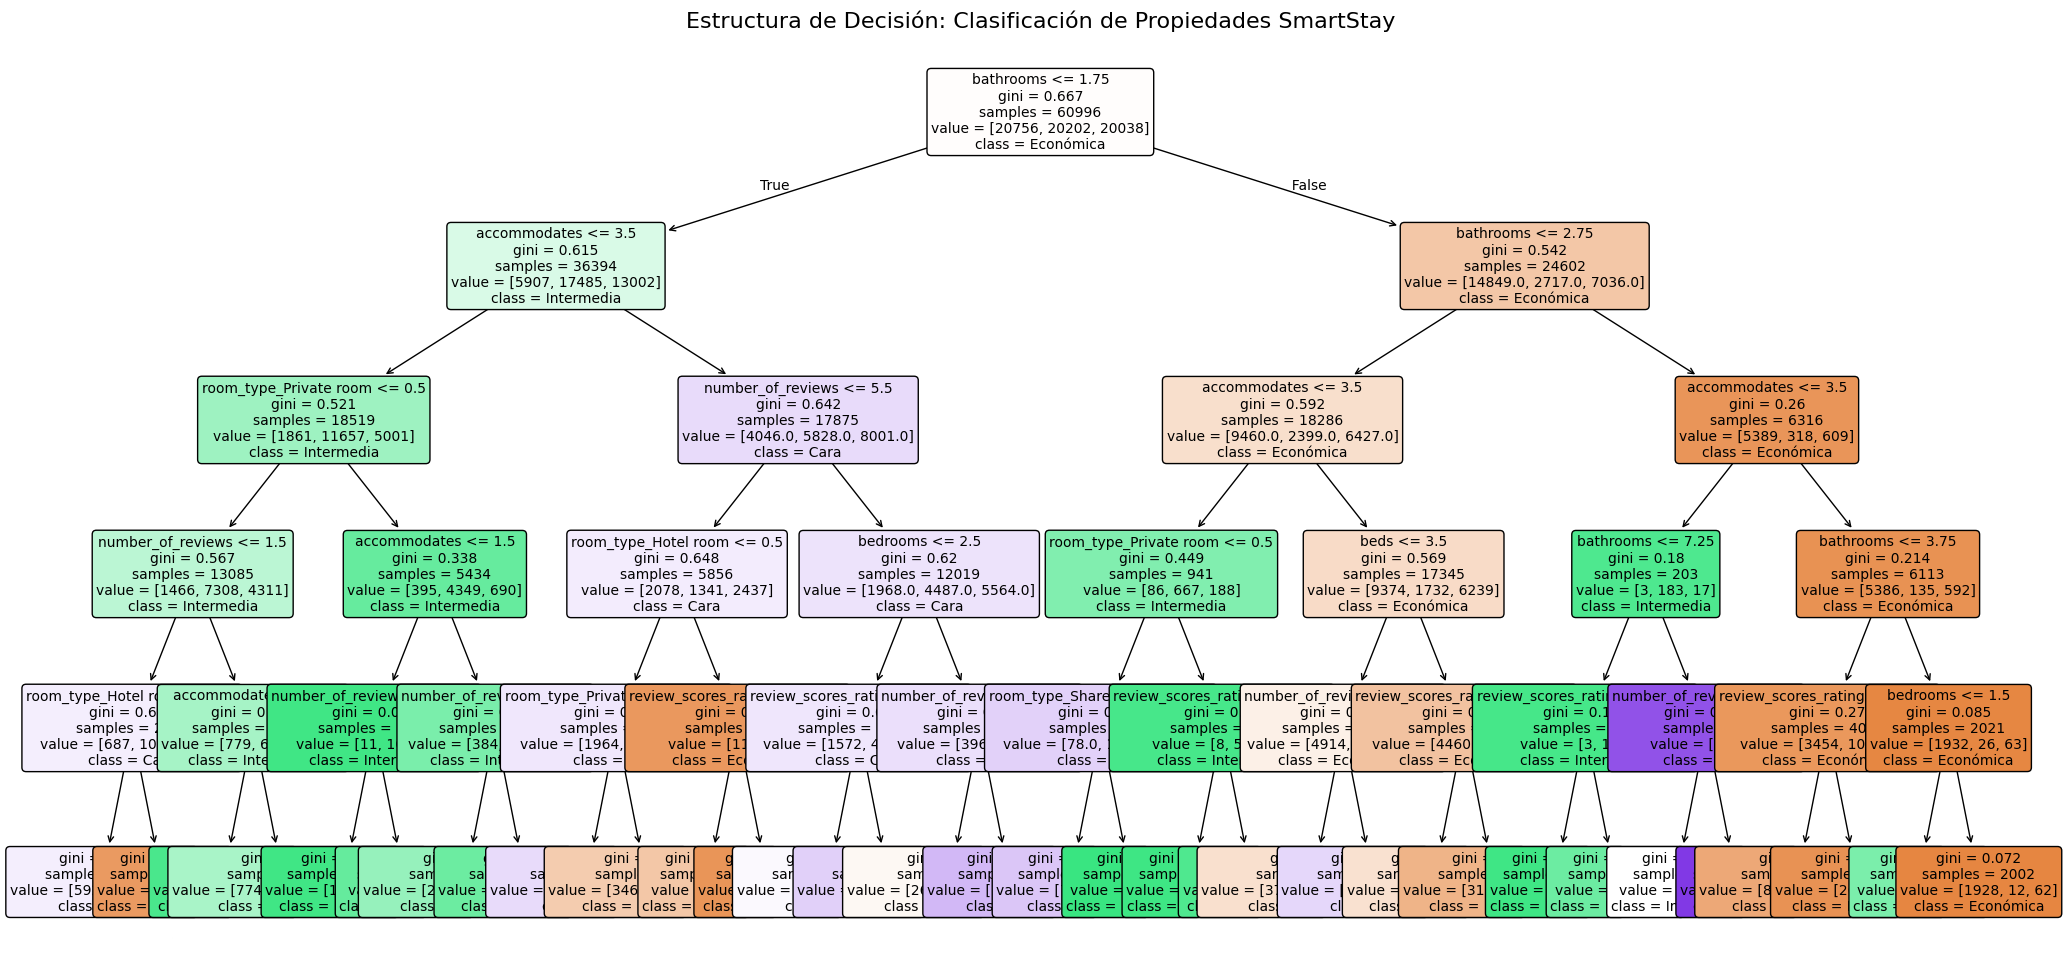

In [7]:
from sklearn.tree import DecisionTreeClassifier

# Variables a reportar en el modelo de clasificación
features_clas = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating'
]

X_clas = df_model[features_clas].copy()
for col in features_clas:
    X_clas[col] = pd.to_numeric(X_clas[col], errors='coerce')

if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))
y_clas = df_model['categoria_precio'].copy()

# Reutilizar exactamente la misma partición de entrenamiento y prueba del modelo de regresión
train_idx = X_train.index
test_idx = X_test.index

X_train_c = X_clas.loc[train_idx].copy()
X_test_c = X_clas.loc[test_idx].copy()
y_train_c = y_clas.loc[train_idx].copy()
y_test_c = y_clas.loc[test_idx].copy()

labels_orden = ['Económica', 'Intermedia', 'Cara']

print('Variables predictoras reportadas para el árbol de clasificación:')
print(X_clas.columns.tolist())
print(f'Total de predictores utilizados: {X_clas.shape[1]}')
print(f'Filas de entrenamiento: {X_train_c.shape[0]} | Filas de prueba: {X_test_c.shape[0]}')

modelo_clas = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')
modelo_clas.fit(X_train_c, y_train_c)

y_pred_c = modelo_clas.predict(X_test_c)
accuracy_clas = accuracy_score(y_test_c, y_pred_c)
reporte_clas = pd.DataFrame(classification_report(y_test_c, y_pred_c, output_dict=True)).transpose()
importancias_clas = pd.Series(modelo_clas.feature_importances_, index=X_clas.columns).sort_values(ascending=False)

print(f'\nExactitud preliminar del árbol de clasificación: {accuracy_clas:.4f}')
print('\nImportancia relativa de las variables:')
print(importancias_clas.head(10).round(4).to_string())

plt.figure(figsize=(25, 12))
plot_tree(
    modelo_clas,
    feature_names=X_clas.columns,
    class_names=labels_orden,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Estructura de Decisión: Clasificación de Propiedades SmartStay', fontsize=16)
plt.show()


**Análisis y Hallazgos del Árbol de Clasificación (Punto 7):**

1. **Variables determinantes.** En este árbol, `bathrooms` es el predictor más influyente (59.64% de la importancia total), seguido por `accommodates` (22.84%). Después aparecen `number_of_reviews` y `room_type_Private room`, por lo que la segmentación de precios queda explicada principalmente por capacidad, nivel de baños y tipo de hospedaje.

2. **Coherencia metodológica.** El modelo se entrenó sin incluir `price`, `log_price` ni `categoria_precio` como predictores, evitando filtración de información. Además, se reutilizó exactamente la misma partición de entrenamiento y prueba usada antes en el notebook, de modo que la comparación metodológica se mantiene consistente.

3. **Interpretabilidad.** Se mantuvo `max_depth = 5` para conservar un árbol legible para la consultora. Aun con esa restricción, el modelo alcanzó una exactitud preliminar de 0.5942, suficiente para mostrar patrones de decisión útiles sin volver el modelo demasiado complejo de explicar.
